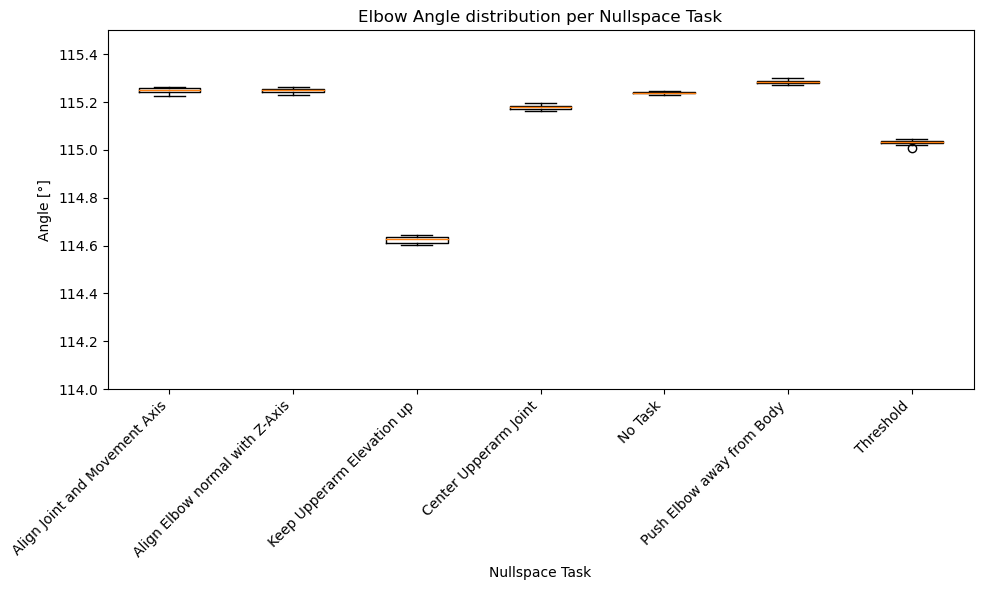

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import re

# Replace with your folder path
folder = Path("/home/bjoern/Projects/Masterarbeit/simdata/nullspace_optimization")

data = {}
pattern = re.compile(r"^\s*\d+\s*:\s*([-+]?\d*\.?\d+)")

for file in sorted(folder.glob("*.txt")):
    values = []

    with open(file, "r") as f:
        for line in f:
            match = pattern.match(line)
            if match:
                values.append(float(match.group(1)))

    if values:
        data[file.stem] = values


label_map = {
    "align_joint_axis": "Align Joint and Movement Axis",
    "align_normal": "Align Elbow normal with Z-Axis",
    "arm_elevation": "Push Upperarm Elevation to 0.5",
    "center_joint": "Center Upperarm Joint",
    "no_nst": "No Task",
    "push_away_from_origin": "Push Elbow away from Body",
    "threshold": "Keep Shoulder Yaw joints above Threshold of 0.3",
}

labels = list(data.keys())
boxplot_data = [data[label] for label in labels]
labels = [label_map.get(name, name.replace("_", " ").title())
          for name in data.keys()]

# Create figure
plt.figure(figsize=(10, 6))
plt.boxplot(boxplot_data, labels=labels)

plt.xlabel("Nullspace Task")
plt.ylabel("Angle [°]")
plt.title("Elbow Angle distribution per Nullspace Task")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.ylim(114.0, 115.5)
plt.show()